# **Proyecto: Análisis estadístico sobre hábitos saludables en jóvenes universitarios**

## **Lección 1: Método científico y estadística**

#### - Definición del problema a investigar

¿Qué patrones comunes y causas probables influyen en los hábitos saludables (hábitos de sueño, alimentación y actividad física) de los jóvenes universitarios?

#### - Formulación de hipótesis nula y alternativa

- **H₀ (Hipótesis nula):** La media de horas de sueño de los estudiantes universitarios es igual a 7 horas (valor de referencia recomendado).
- **H₁ (Hipótesis alternativa):** La media de horas de sueño de los estudiantes universitarios **no** es igual a 7 horas.


#### - Identificación de variables relevantes

| Variable | Tipo       | Descripción                              |
|----------|------------|------------------------------------------|
| `horas_sueno` | Cuantitativa continua | Horas de sueño por noche |
| `horas_estudio` | Cuantitativa continua | Horas de estudio diarias |
| `horas_ejercicio_semana` | Cuantitativa continua | Horas de ejercicio por semana |
| `nivel_estres` | Cuantitativa continua | Nivel de estrés (escala 1–10) |
| `imc` | Cuantitativa continua | Índice de masa corporal |
| `pasos_diarios` | Cuantitativa discreta | Pasos diarios |
| `calidad_alimentacion` | Cuantitativa discreta | Calidad de alimentación (1–5) |
| `consume_alcohol` | Cualitativa binaria | Consume alcohol (0=No, 1=Sí) |
| `edad` | Cuantitativa discreta | Edad del estudiante |


#### - Enfoque del método científico elegido

Se aplica el enfoque **hipotético-deductivo**, partiendo de hipótesis basadas en valores de referencia médicos, las cuales fueron contrastadas con datos reales usando herramientas de inferencia estadística (intervalos de confianza y pruebas de hipótesis).

#### - Diseño preliminar del estudio

El estudio está dado por la encuesta a 500 universitarios sobre sus datos personales, hábitos y datos de salud.
A continuación, se realiza una muestra de la base recopilada.	

In [29]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, binom
from IPython.display import display, HTML

In [30]:
#Leer archivo
df = pd.read_csv("dataset_habitos_saludables_universitarios_500.csv")

Exploración inicial del DataSet

In [31]:
# Dimensiones del DataSet
print("\033[1mDimensiones del DataSet:\033[0m\n")
print( f"Filas: {df.shape[0]}" )
print( f"Columnas: {df.shape[1]}")

Dimensiones del DataSet:

Filas: 500
Columnas: 10


In [32]:
#Información de variables del DataSet
print("\033[1mInformación de variables\033[0m\n")
print( df.info() )


Información de variables

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_estudiante           500 non-null    int64  
 1   edad                    500 non-null    int64  
 2   horas_sueno             500 non-null    float64
 3   horas_estudio           500 non-null    float64
 4   horas_ejercicio_semana  500 non-null    float64
 5   nivel_estres            500 non-null    float64
 6   calidad_alimentacion    500 non-null    int64  
 7   consume_alcohol         500 non-null    int64  
 8   imc                     500 non-null    float64
 9   pasos_diarios           500 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 39.2 KB
None


In [33]:
print("\033[1mEstadísticas descriptivas\033[0m\n")
pd.set_option('display.float_format', '{:.3f}'.format)
display( df.describe() )
pd.reset_option('display.float_format')

Estadísticas descriptivas



,id_estudiante,edad,horas_sueno,horas_estudio,horas_ejercicio_semana,nivel_estres,calidad_alimentacion,consume_alcohol,imc,pasos_diarios
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,250.500,23.900,7.037,3.647,2.991,3.070,2.904,0.370,22.766,8170.124
std,144.482,3.775,1.070,1.277,1.408,1.347,1.442,0.483,3.395,1976.149
min,1.000,18.000,3.640,0.370,0.000,1.000,1.000,0.000,16.000,3176.000
25%,125.750,21.000,6.320,2.777,1.970,1.988,2.000,0.000,20.495,6829.000
50%,250.500,24.000,7.060,3.580,3.040,3.040,3.000,0.000,22.775,8084.000
75%,375.250,27.000,7.810,4.492,3.968,3.990,4.000,1.000,24.885,9492.250
max,500.000,30.000,10.000,7.300,7.050,7.390,5.000,1.000,32.630,15315.000


In [34]:
#Vista previa de DataSet
print("\033[1mVisualización primeras 5 filas\033[0m\n")
pd.set_option("display.max_columns", None)
display(df.head() )


Visualización primeras 5 filas



,id_estudiante,edad,horas_sueno,horas_estudio,horas_ejercicio_semana,nivel_estres,calidad_alimentacion,consume_alcohol,imc,pasos_diarios
0,1,24,8.78,3.49,4.02,1.96,4,0,24.12,5429
1,2,21,6.32,5.13,2.59,2.79,2,1,23.45,7925
2,3,30,5.45,3.32,1.88,3.89,3,1,24.45,8276
3,4,28,6.66,2.68,4.30,3.49,3,0,20.75,6945
4,5,25,7.18,5.67,4.70,1.62,5,1,27.03,8808


## **Lección 2: Probabilidad y estadística**

Se definen como elementos aleatorios a:
- Dormir más de 7 horas
- Consume alcohol

También, se define el tipo de muestreo como muestreo aleatorio estratificado, ya que, va a estar determinado por los hábitos de los estudiantes universitarios.

A continuación, se calcularán las probabilidades de los eventos aleatorios, así como también, la intersección, unión y complementos.

In [35]:
#Calculo de probabilidades básicad
p_dormir_mas7  = (df['horas_sueno'] > 7).mean()
p_alcohol      = df['consume_alcohol'].mean()
p_no_alcohol   = 1 - p_alcohol   # Complemento
p_interseccion = ((df['horas_sueno'] > 7) & (df['consume_alcohol'] == 1)).mean()  # Intersección
p_union        = ((df['horas_sueno'] > 7) | (df['consume_alcohol'] == 1)).mean()  # Unión

df_prob = pd.DataFrame({
    "Evento": ["P(duerme > 7 horas)", "P(consume alcohol)", "P(NO consume alcohol) [complemento]",
               "P(duerme>7 Y consume alcohol) [intersección]", "P(duerme>7 O consume alcohol) [unión]"],
    "Probabilidad": [p_dormir_mas7, p_alcohol, p_no_alcohol, p_interseccion, p_union]})

display(df_prob.style.format({"Probabilidad": "{:.3f}"}))


,Evento,Probabilidad
0,P(duerme > 7 horas),0.528
1,P(consume alcohol),0.370
2,P(NO consume alcohol) [complemento],0.630
3,P(duerme>7 Y consume alcohol) [intersección],0.196
4,P(duerme>7 O consume alcohol) [unión],0.702


Además, se comprueba si la regla de la adición se cumple cuando los eventos aleatorios no son excluyentes entre sí con la siguiente fórmula: 

**<center>P(A∪B)=P(A)+P(B)-P(A∩B)</center>**

In [36]:
# Verificación de la regla de la adición
p_union_calculada = p_dormir_mas7 + p_alcohol - p_interseccion
print()
print( f"Verificación P(A∪B)=P(A)+P(B)-P(A∩B): {p_union_calculada:.3f} ≈ {p_union:.3f}" )


Verificación P(A∪B)=P(A)+P(B)-P(A∩B): 0.702 ≈ 0.702


Tras la comprobación de la verificación se concluye que, las probabilidades fueron bien calculadas mostrando su coherencia con obtener valores de aproximadamente iguales.

A partir de las probabilidades de los eventos aleatorios se procedio a confeccionar el árbol de probabilidad.

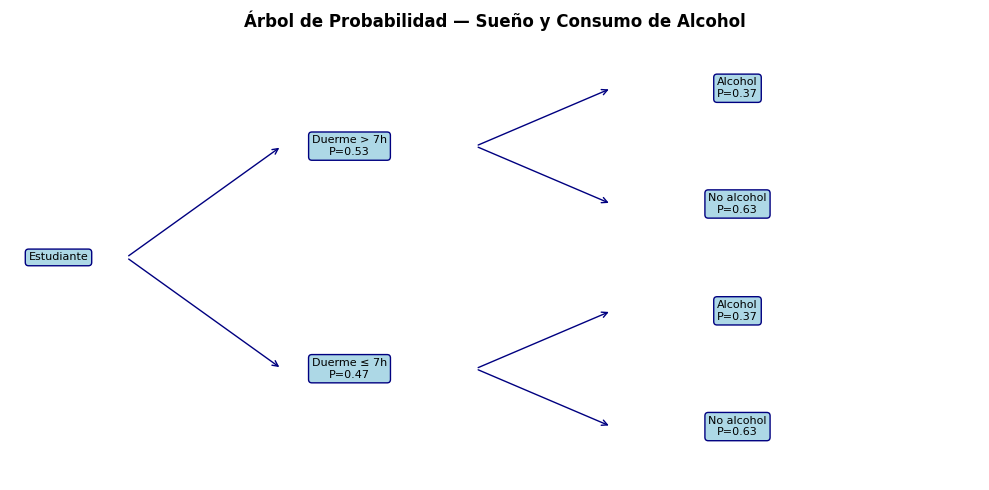

In [37]:
# Árbol de probabilidad simplificado (visualización)
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Nodos del árbol
nodes = [
  (0.05, 0.5, 'Estudiante'),
  (0.35, 0.75, f'Duerme > 7h\nP={p_dormir_mas7:.2f}'),
  (0.35, 0.25, f'Duerme ≤ 7h\nP={1-p_dormir_mas7:.2f}'),
  (0.75, 0.88, f'Alcohol\nP={p_interseccion/p_dormir_mas7:.2f}'),
  (0.75, 0.62, f'No alcohol\nP={1-p_interseccion/p_dormir_mas7:.2f}'),
  (0.75, 0.38, f'Alcohol\nP={((df["horas_sueno"]<=7)&(df["consume_alcohol"]==1)).mean()/(1-p_dormir_mas7):.2f}'),
  (0.75, 0.12, f'No alcohol\nP={((df["horas_sueno"]<=7)&(df["consume_alcohol"]==0)).mean()/(1-p_dormir_mas7):.2f}'),
]

# Dibujar nodos
for x, y, label in nodes:
  ax.text(x, y, label, ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", edgecolor="navy"),
    fontsize=8)

# Dibujar líneas
lines = [(0.12,0.5,0.28,0.75),(0.12,0.5,0.28,0.25),
         (0.48,0.75,0.62,0.88),(0.48,0.75,0.62,0.62),
         (0.48,0.25,0.62,0.38),(0.48,0.25,0.62,0.12)]
for x1,y1,x2,y2 in lines:
  ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
    arrowprops=dict(arrowstyle="->", color="navy"))

ax.set_title("Árbol de Probabilidad — Sueño y Consumo de Alcohol", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Por último, se presenta la vista previa de un ejemplo de simulación del muestreo aleatorio estratificado (con igual tamaño por estrato).

In [38]:
df_simulacion = df.copy()

df_simulacion["estrato"] = np.select(
    [(df_simulacion["horas_sueno"] > 7) & (df_simulacion["consume_alcohol"] == 1),
     (df_simulacion["horas_sueno"] > 7) & (df_simulacion["consume_alcohol"] == 0),
     (df_simulacion["horas_sueno"] <= 7) & (df_simulacion["consume_alcohol"] == 1),
     (df_simulacion["horas_sueno"] <= 7) & (df_simulacion["consume_alcohol"] == 0)],
    ["duerme>7 & alcohol", "duerme>7 & no_alcohol", "duerme<=7 & alcohol", "duerme<=7 & no_alcohol"],
    default="sin_clasificar"
    )

muestra_igual = (df_simulacion.groupby("estrato", group_keys=False).apply(lambda g: g.sample(n=25, random_state=42)))
display(muestra_igual)


,id_estudiante,edad,horas_sueno,horas_estudio,horas_ejercicio_semana,nivel_estres,calidad_alimentacion,consume_alcohol,imc,pasos_diarios
418,419,28,6.96,3.50,2.36,3.94,1,1,17.98,8212
1,2,21,6.32,5.13,2.59,2.79,2,1,23.45,7925
140,141,22,5.65,3.55,2.42,5.63,3,1,27.87,7657
135,136,19,6.40,3.27,2.35,3.64,2,1,20.82,8961
82,83,30,6.66,3.67,3.77,2.97,1,1,23.73,5312
...,...,...,...,...,...,...,...,...,...,...
231,232,18,7.51,3.04,4.53,3.88,2,0,20.05,12270
47,48,22,8.28,4.62,2.39,4.00,4,0,26.64,9040
32,33,30,7.48,2.92,2.97,1.71,2,0,20.56,6665
27,28,22,7.93,3.35,4.04,1.72,3,0,24.32,3421


## **Lección 3: Distribución de probabilidad**

<div style="text-align: justify;"> 

Para la variable de *horas_sueno* como sus valores son números continuos se aplicó la distribución normal o gaussiana. Esto se debe a que la estadística descriptiva de *horas_sueno* muestra que los valores tienden a agruparse alrededor de la media como se puede ver en los campos resaltados de la siguiente imagen.


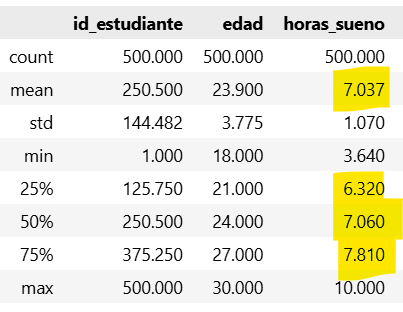

A continuación se calcularán las probabilidades para la variable *horas_sueno*.</div>

In [39]:
# Distribución NORMAL para horas_sueno
media_s = df['horas_sueno'].mean()
std_s   = df['horas_sueno'].std()

# Probabilidades con la distribución normal
p_menos6  = norm.cdf(6, loc=media_s, scale=std_s)
p_entre67 = norm.cdf(7, loc=media_s, scale=std_s) - norm.cdf(6, loc=media_s, scale=std_s)
p_mas8    = 1 - norm.cdf(8, loc=media_s, scale=std_s)

#Visualización resultado
df_prob2 = pd.DataFrame({
    "Parámetro": ["Media", "Desv. estándar","P(dormir < 6h) ","P(6h ≤ dormir < 7h)","P(dormir > 8h)"],
    "Valor": [media_s, std_s, p_menos6, p_entre67, p_mas8]
})

display(HTML("<h3>Distribución Normal — Horas de sueño</h3>"))
display(df_prob2.style.format({"Valor": "{:.4f}"}))

,Parámetro,Valor
0,Media,7.0368
1,Desv. estándar,1.0701
2,P(dormir < 6h),0.1663
3,P(6h ≤ dormir < 7h),0.3200
4,P(dormir > 8h),0.1841


<div style="text-align: justify;">

De la tabla, se obtiene que:
- Se tiene una probabilidad del 16,7% de que un universitario duerma menos de seis horas.
- Se tiene una probabilidad del 32% de que un universitario duerma entre seis y siete horas.
- Se tiene una probabilidad del 18,4% de que un universitario duerma más de ocho horas.


 De igual forma, se graficó la distribución normal de *horas_sueno*. La gráfica presenta que las barras del histograma de los valores de las horas de sueños se amoldan de forma casi perfecta a la curva de la distribución. Asimismo, las observaciones se concentran entre las 6 y 8 horas, a pesar de que el rango de horas de sueño va desde 3 a 10 horas.

 </div>

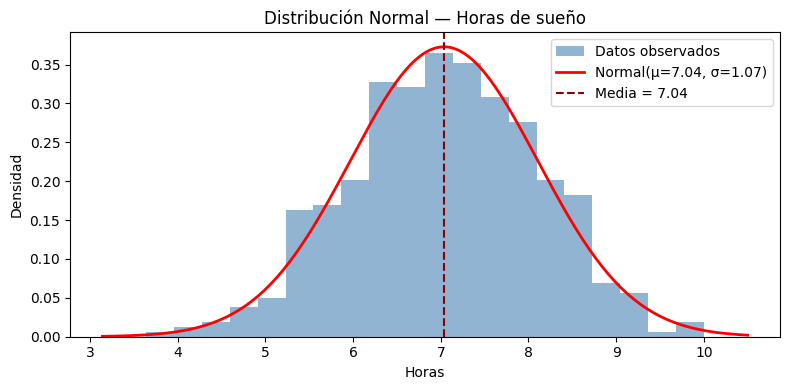

In [40]:
x = np.linspace(df["horas_sueno"].min()-0.5, df["horas_sueno"].max()+0.5, 200)
y = norm.pdf(x, media_s, std_s)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["horas_sueno"], bins=20, density=True, alpha=0.6, color="steelblue", label="Datos observados")
ax.plot(x, y, "r-", lw=2, label=f"Normal(μ={media_s:.2f}, σ={std_s:.2f})")
ax.axvline(media_s, color="darkred", linestyle="--", label=f"Media = {media_s:.2f}")
ax.set_title("Distribución Normal — Horas de sueño")
ax.set_xlabel("Horas"); ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()

<div style="text-align: justify;">


Por otro lado, la variable de *consume_alcohol* es una varible discreta, por lo cual se aplica la distribución binomial. Esto se debe a que *consume_alcohol* es binaria, es decir, posee dos posibles valores: "1" si consume alcohol y "0" si NO consume alcohol. Y también porque surge al repetirse de manera independiente n veces.

En siguiente se calculan las probabilidades básicas para *consume_alcohol*.
</div>

In [41]:
#Distribución binomial
n_grupo = 10
p_alc   = df["consume_alcohol"].mean()

k_values = np.arange(0, n_grupo + 1)
prob_binom = binom.pmf(k_values, n_grupo, p_alc)

#Probabilidad distribución binomial
prob_exactamente_3 = binom.pmf(3, n_grupo, p_alc)
prob_al_menos_5   = 1 - binom.cdf(4, n_grupo, p_alc)

#Visualización resultado
df_prob3 = pd.DataFrame({
    "Parámetro": ["n_estudiantes ", "p","P(exactamente 3 consumen alcohol)","P(al menos 5 consumen alcohol)"],
    "Valor": [n_grupo, p_alc, prob_exactamente_3, prob_al_menos_5]
})

display(HTML("<h3>Distribución Binomial — Consumo de alcohol</h3>"))
display(df_prob3.style.format({"Valor": "{:.4f}"}))

,Parámetro,Valor
0,n_estudiantes,10.0000
1,p,0.3700
2,P(exactamente 3 consumen alcohol),0.2394
3,P(al menos 5 consumen alcohol),0.2939


<div style="text-align: justify;">


De la tabla anterior se concluye que:
- Se obtiene una probabilidad de 23,9% de que, 3 de cada 10 universitarios consuman alcohol.
- Se obtiene una probabilidad de 29,4% de que al menos 5 de cada 10 universitarios consuman alcohol.

Además, se elaboró el gráfico con la distribución binomial de *consume_alcohol*. 
</div>

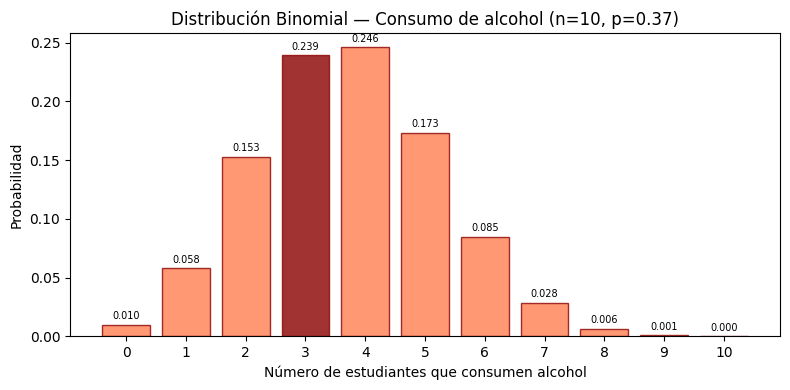

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(k_values, prob_binom, color="coral", edgecolor="darkred", alpha=0.8)
bars[3].set_color("darkred")
ax.set_title(f"Distribución Binomial — Consumo de alcohol (n={n_grupo}, p={p_alc})")
ax.set_xlabel("Número de estudiantes que consumen alcohol")
ax.set_ylabel("Probabilidad")
ax.set_xticks(k_values)
for bar, prob in zip(bars, prob_binom):
  ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
    f"{prob:.3f}", ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()

<div style="text-align: justify;">

Del gráfico se aprecia que la mayor concentración de la probabilidad está entre 2 y 5 estudiantes universitarios. Al mismo tiempo, los valores extremos como 9 o 10 estudiantes tienen probabilidades muy bajas sobre el consumo de alcohol.

</div>

## **Lección 4: Distribución muestral y teorema del límite central**

<div style="text-align: justify;">

Se generaron distribuciones muestrales de media de tamaños de 5, 15, 30 y 100 de *horas_sueno* cada una repetida 1000 veces. A quienes se le aplicó el Teorema del Límite Central y el resultado se puede observar en la gráfica de a continuación.
</div>

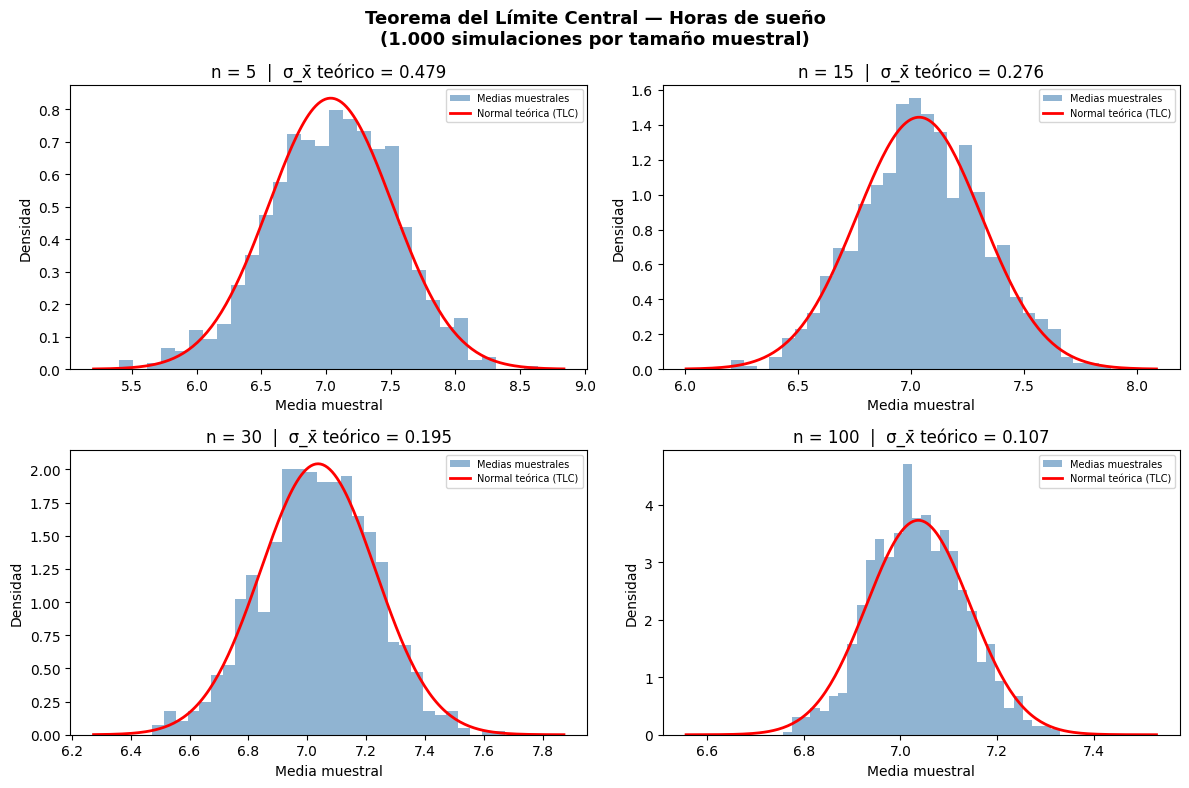

In [43]:
np.random.seed(42)
tamaños = [5, 15, 30, 100]
n_simulaciones = 1_000

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, n in enumerate(tamaños):
  medias = [df["horas_sueno"].sample(n).mean() for _ in range(n_simulaciones)]
  error_teorico = df["horas_sueno"].std() / np.sqrt(n)

  ax = axes[i]
  ax.hist(medias, bins=30, density=True, alpha=0.6, color="steelblue", label="Medias muestrales")

  # Curva normal teórica
  x = np.linspace(min(medias)-0.2, max(medias)+0.2, 200)
  ax.plot(x, norm.pdf(x, df["horas_sueno"].mean(), error_teorico),
    "r-", lw=2, label="Normal teórica (TLC)")

  ax.set_title(f"n = {n}  |  σ_x̄ teórico = {error_teorico:.3f}")
  ax.set_xlabel("Media muestral"); ax.set_ylabel("Densidad")
  ax.legend(fontsize=7)

fig.suptitle("Teorema del Límite Central — Horas de sueño\n(1.000 simulaciones por tamaño muestral)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

<div style="text-align: justify;">

En el gráfico *n=5 y σ_x̄ teórico= 0.479* la distribución de las medias es ancha y bajita, lo cual se debe al tamaño muestral que provoca que las medias sean más variables.

En el gráfico *n=15 y σ_x̄ teórico= 0.276* la distribución de medias se concentra alrededor de la media real. La forma de la distribución se acerca más a una distribución normal y la TLC toma mejor figura.

En el gráfico *n=30 y σ_x̄ teórico= 0.195* la TLC calza casi perfectamente con el histograma y la dispersión de las medias disminuye.

En el gráfico *n=100 y σ_x̄ teórico= 0.107* la distribución de las medias es más concentrada que los anteriores gráficos y la TLC se amolda de forma casi idéntica con el histograma.

En conclusión, a medida que aumenta el tamaño muestral, la distribución de las medias se vuelve más normal y disminuye la variabilidad de estas. Esto concuerda con lo que postula el Teorema del Límite Central que con un número suficiente grande de muestras, la distribución de las medias muestrales se acerca a una distribución normal.


Por otro lado, se procede a analizar la dispersión de la media según tamaño muestral.

</div>

In [44]:
#Dispersión de la media según tamaño muestral
resultados = []

for n in tamaños:
  medias = [df["horas_sueno"].sample(n).mean() for _ in range(n_simulaciones)]
  teo = df["horas_sueno"].std() / np.sqrt(n)
  emp = np.std(medias)
    
  resultados.append({"n": n, "σ_x̄ teórico": round(teo, 4), "σ_x̄ empírico": round(emp, 4) })

tabla = pd.DataFrame(resultados)

display(HTML("<h3>Dispersión de la media según tamaño muestral</h3>"))
display(tabla.style.format({"σ_x̄ teórico": "{:.4f}", "σ_x̄ empírico": "{:.4f}"}))

,n,σ_x̄ teórico,σ_x̄ empírico
0,5,0.4786,0.4764
1,15,0.2763,0.2694
2,30,0.1954,0.1899
3,100,0.1070,0.0916


<div style="text-align: justify;">

De la presente tabla se aprecia que, la dispersión de la media tanto teórica como empírica disminuye a medida que aumenta el tamaño muestral. También, los valores empíricos se acercan a los valores teóricos, lo cual indicaría que los datos se comportan según lo predicho por la estadística (Ley de los Grandes Números).


Finalmente, se compara la distribución poblacional con la muestral.

</div>

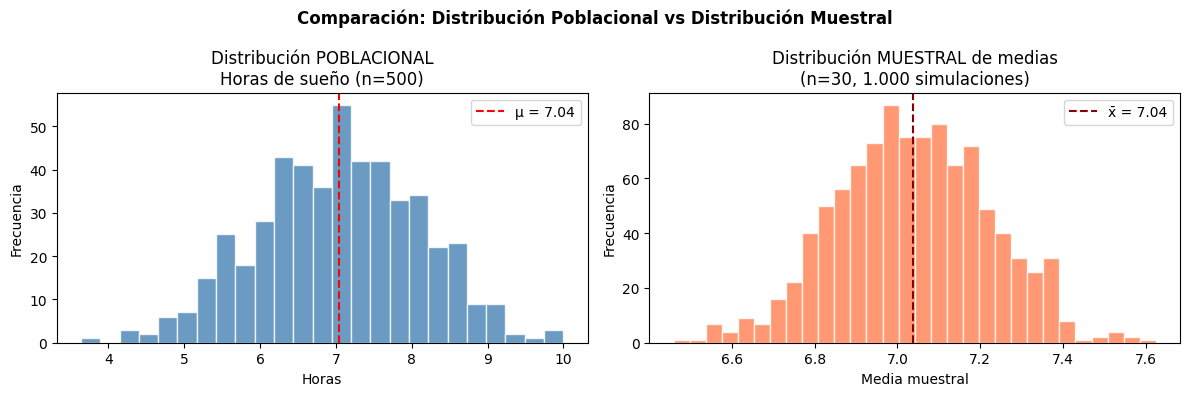

In [45]:
# Comparación distribución poblacional vs distribución muestral (n=30)
np.random.seed(42)
medias_n30 = [df["horas_sueno"].sample(30).mean() for _ in range(1_000)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["horas_sueno"], bins=25, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribución POBLACIONAL\nHoras de sueño (n=500)")
axes[0].set_xlabel("Horas"); axes[0].set_ylabel("Frecuencia")
axes[0].axvline(df["horas_sueno"].mean(), color="red", linestyle="--",
      label=f'μ = {df["horas_sueno"].mean():.2f}')
axes[0].legend()

axes[1].hist(medias_n30, bins=30, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribución MUESTRAL de medias\n(n=30, 1.000 simulaciones)")
axes[1].set_xlabel("Media muestral"); axes[1].set_ylabel("Frecuencia")
axes[1].axvline(np.mean(medias_n30), color='darkred', linestyle="--",
      label=f"x̄ = {np.mean(medias_n30):.2f}")
axes[1].legend()

plt.suptitle("Comparación: Distribución Poblacional vs Distribución Muestral", fontweight="bold")
plt.tight_layout()
plt.show()

<div style="text-align: justify;">

El gráfico de distribución poblacional muestra los datos individuales de *horas_sueno* que tienen una alta dispersión.

El gráfico de distribución muestral representa las medias de las muestras con una baja dispersión.

De estos dos gráficos se concluye que, las medias muestrales son menos variables que los datos individuales y se concentran alrededor del valor poblacional como indica el Teorema del Límite Central. 

</div>

## **Lección 5: Inferencia e intervalos de confianza para la media**

<div style="text-align: justify;">

Con el objetivo de calcular los intervalos de confianza para la media se definió la función *intervalo_confianza*.

</div>

In [46]:
def intervalo_confianza(data, nivel):
  """
  Calcula IC para la media usando la distribución normal.
  """
  n     = len(data)
  media = data.mean()
  std   = data.std()
  alpha = 1 - nivel
  z     = norm.ppf(1 - alpha / 2)
  error = z * std / np.sqrt(n)
  return media - error, media + error, error

In [47]:
variables = {"horas_sueno": "Horas de Sueño","horas_ejercicio_semana": "Horas de Ejercicio/Semana"}

niveles = [0.90, 0.95, 0.99]

for col, nombre in variables.items():
    filas = []

    for niv in niveles:
        li, ls, err = intervalo_confianza(df[col], niv)
        filas.append({"Confianza": f"{int(niv*100)}%", "Límite inf": round(li, 4), 
                      "Límite sup": round(ls, 4), "Ancho IC": round(2*err, 4)})

    tabla = pd.DataFrame(filas)

    titulo = f"<h3>{nombre} (μ = {df[col].mean():.4f})</h3>"
    display(HTML(titulo))
    display(tabla)


,Confianza,Límite inf,Límite sup,Ancho IC
0,90%,6.9581,7.1156,0.1574
1,95%,6.9430,7.1306,0.1876
2,99%,6.9136,7.1601,0.2465


,Confianza,Límite inf,Límite sup,Ancho IC
0,90%,2.8876,3.0947,0.2071
1,95%,2.8677,3.1145,0.2468
2,99%,2.8290,3.1533,0.3243


<div style="text-align: justify;">

Al sacar los intervalos de confianza de las medias de las variables *horas_sueno* y *horas_ejercicio_semana* con niveles de confianza al 90%, 95% y 99% se obtuvo que:

- Hay un 90% de confianza de que la media poblacional se encuentre entre 6,96 y 7,12 horas de sueño.
- Hay un 95% de confianza de que la media poblacional se encuentre entre 6,94 y 7,13 horas de sueño.
- Hay un 99% de confianza de que la media poblacional se encuentre entre 6,91 y 7,16 horas de sueño.
- Hay un 90% de confianza de que la media poblacional se encuentre entre 2,89 y 3,09 horas de ejercicio a la semana.
- Hay un 95% de confianza de que la media poblacional se encuentre entre 2,87 y 3,11 horas de ejercicio a la semana.
- Hay un 99% de confianza de que la media poblacional se encuentre entre 2,83 y 3,15 horas de ejercicio a la semana.
- **El ancho del intervalo de confianza se vuelve más ancho a medida que aumenta el nivel de confianza para cada una de las variables y con ello, baja la precisión para encontrar la media poblacional.**


</div>

<div style="text-align: justify;">

Por último, se evalúa el impacto del tamaño muestral sobre el ancho del intervalo.

</div>

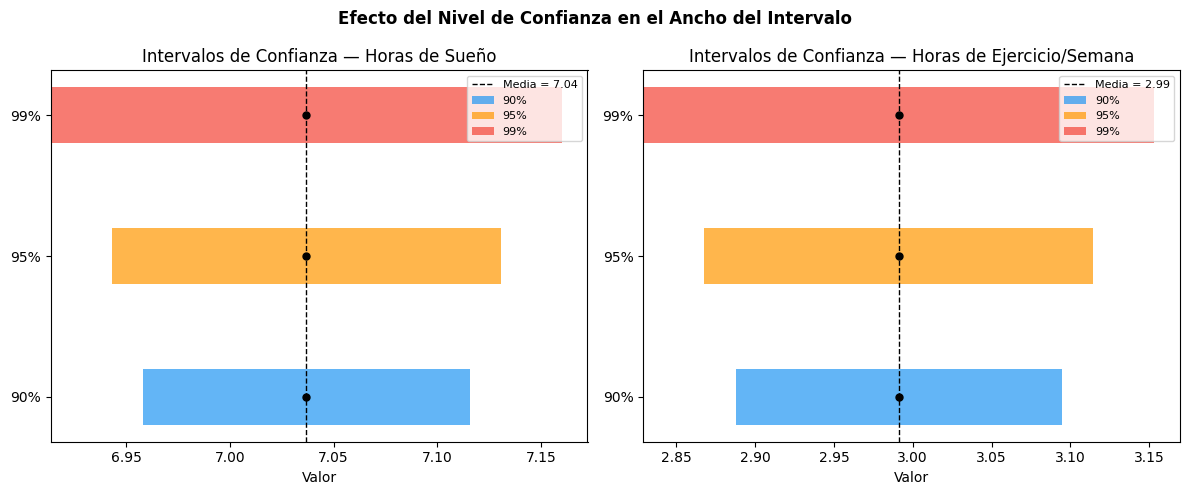

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colores = ["#2196F3", "#FF9800", "#F44336"]
labels  = ["90%", "95%", "99%"]

for ax, (col, nombre) in zip(axes, variables.items()):
  media = df[col].mean()
  for j, niv in enumerate(niveles):
    li, ls, _ = intervalo_confianza(df[col], niv)
    ax.barh(j, ls - li, left=li, height=0.4, color=colores[j], alpha=0.7, label=labels[j])
    ax.plot(media, j, "ko", ms=5)
  ax.set_yticks(range(len(niveles)))
  ax.set_yticklabels(labels)
  ax.set_xlabel("Valor")
  ax.set_title(f"Intervalos de Confianza — {nombre}")
  ax.axvline(media, color="black", linestyle="--", lw=1, label=f"Media = {media:.2f}")
  ax.legend(fontsize=8)

plt.suptitle("Efecto del Nivel de Confianza en el Ancho del Intervalo", fontweight="bold")
plt.tight_layout()
plt.show()

<div style="text-align: justify;">

Como se pudo observar en los gráficos de los intervalos de confianza de las variables *horas_sueno* y *horas_ejercicio_semana*, el ancho del intervalo es mayor a medida que también es mayor el nivel de confianza. Del mismo modo, aumenta la probabilidad de capturar la media, pero disminuye la precisión de la estimación.

Además, con *n=500* los intervalos de confianza son estrechos, lo que indicaría estimaciones más precisas.


</div>

## **Lección 6: Test de significancia**

<div style="text-align: justify;">

Se realiza el test t de hipótesis para la media de la variable *horas_sueno*, con alfa de 0,05.


</div>

In [64]:
mu_0 = 7
alpha = 0.05
t_stat, p_value = stats.ttest_1samp(df["horas_sueno"], mu_0)

display(HTML("<h3>Test t de hipótesis — Horas de sueño</h3>"))
print( f"H₀: μ = {mu_0}   |   H₁: μ ≠ {mu_0}")
print( f"Estadístico t = {t_stat:.4f}")
print( f"p-value       = {p_value:.4f}")
print( f"Nivel α       = {alpha}")

print()

if p_value < alpha:
  print( "Decisión: RECHAZAR H₀" )
  print( f"   El p-value ({p_value:.4f}) < α ({alpha}). Hay evidencia estadística para afirmar" )
  print( f"   que la media de sueño difiere de {mu_0} horas." )
else:
  print( "Decisión: NO rechazar H₀" )
  print( f"   El p-value ({p_value:.4f}) ≥ α ({alpha}). No hay suficiente evidencia para afirmar" )
  print( f"   que la media de sueño difiere de {mu_0} horas." )

H₀: μ = 7   |   H₁: μ ≠ 7
Estadístico t = 0.7698
p-value       = 0.4418
Nivel α       = 0.05

Decisión: NO rechazar H₀
   El p-value (0.4418) ≥ α (0.05). No hay suficiente evidencia para afirmar
   que la media de sueño difiere de 7 horas.


Adicionalmente, se visualiza el análisis anterior.

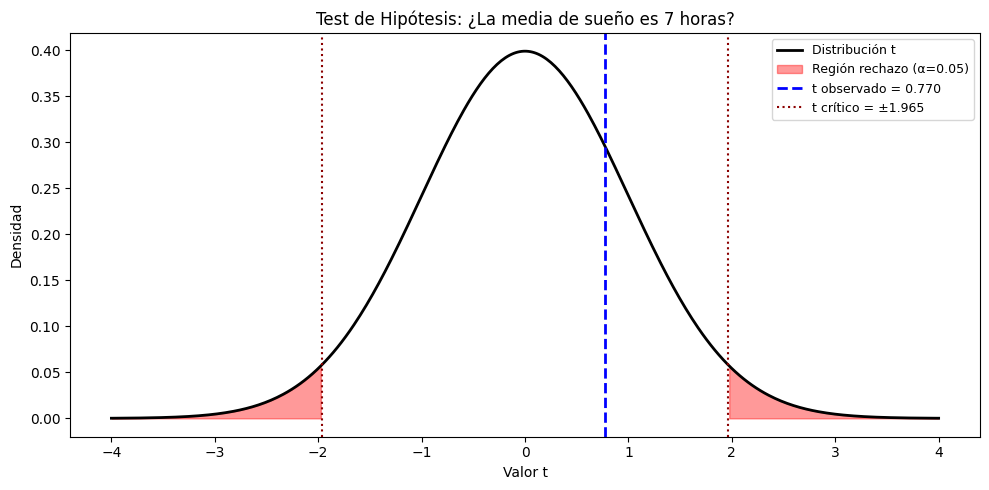

In [50]:
# Visualización del test de hipótesis
fig, ax = plt.subplots(figsize=(10, 5))

gl = len(df) - 1
x  = np.linspace(-4, 4, 400)
y  = stats.t.pdf(x, df=gl)

ax.plot(x, y, "k-", lw=2, label="Distribución t")

# Región de rechazo (bilateral)
t_crit = stats.t.ppf(1 - alpha/2, df=gl)
ax.fill_between(x, y, where=(x <= -t_crit), color="red", alpha=0.4, label=f"Región rechazo (α={alpha})")
ax.fill_between(x, y, where=(x >= t_crit), color="red", alpha=0.4)

# Estadístico observado
ax.axvline(t_stat, color="blue", linestyle="--", lw=2, label=f"t observado = {t_stat:.3f}")
ax.axvline(-t_crit, color="darkred", linestyle=":", lw=1.5, label=f"t crítico = ±{t_crit:.3f}")
ax.axvline(t_crit, color="darkred", linestyle=":", lw=1.5)

ax.set_title("Test de Hipótesis: ¿La media de sueño es 7 horas?", fontsize=12)
ax.set_xlabel("Valor t"); ax.set_ylabel("Densidad")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Se evalúan los errores tipo I y II para las horas del sueño.

In [66]:
# Errores Tipo I y Tipo II
display(HTML("<h3>Errores Tipo I y Tipo II</h3>"))
print( "Error Tipo I (α):  Rechazar H₀ cuando es verdadera." )
print( f"  -> Probabilidad fijada: α = {alpha}" )
print(  "  -> En este contexto: concluir que los estudiantes NO duermen 7h cuando sí lo hacen." )
print()
print( "Error Tipo II (β): No rechazar H₀ cuando es falsa." )
print( "  -> En este contexto: concluir que los estudiantes SI duermen 7h cuando no lo hacen." )
print()

# Potencia del test (ejemplo con desplazamiento de 0.5h)
delta = 0.5
mu_alt = mu_0 + delta
error_estandar = df["horas_sueno"].std() / np.sqrt(len(df))
t_crit_val = stats.t.ppf(1 - alpha/2, df=len(df)-1)

# Potencia aproximada
nc = delta / error_estandar
potencia = 1 - stats.t.cdf(t_crit_val - nc, df=len(df)-1) + stats.t.cdf(-t_crit_val - nc, df=len(df)-1)
print( f"Potencia del test (μ_alt = {mu_alt}): {potencia:.4f}" )
print( f"Error Tipo II estimado (β): {1-potencia:.4f}" )

Error Tipo I (α):  Rechazar H₀ cuando es verdadera.
  -> Probabilidad fijada: α = 0.05
  -> En este contexto: concluir que los estudiantes NO duermen 7h cuando sí lo hacen.

Error Tipo II (β): No rechazar H₀ cuando es falsa.
  -> En este contexto: concluir que los estudiantes SI duermen 7h cuando no lo hacen.

Potencia del test (μ_alt = 7.5): 1.0000
Error Tipo II estimado (β): 0.0000


Finalmente, se presentan las principales conluciones del proyecto de Análisis estadístico sobre hábitos saludables en jóvenes universitarios.

In [52]:
print("=" * 60)
print( f"{'CONCLUSIONES FINALES DEL ESTUDIO':^60}")
print("=" * 60)

li2, ls2, _ = intervalo_confianza(df["horas_ejercicio_semana"], 0.95)

print()
print( "1. SUEÑO" )
print( f'   Media observada: {df["horas_sueno"].mean():.2f}h')
print( f'   IC 95%: ({intervalo_confianza(df["horas_sueno"], 0.95)[0]:.2f}, '
       f'{intervalo_confianza(df["horas_sueno"], 0.95)[1]:.2f})')
print(f'   Test H₀ (μ=7): p={p_value:.4f} -> No se rechaza H₀.')
print(f'   Los estudiantes duermen en promedio ~7h, dentro del rango recomendado.')

print()
print('2. ACTIVIDAD FÍSICA')
print(f'   Media: {df["horas_ejercicio_semana"].mean():.2f}h/semana, IC 95%: ({li2:.2f}, {ls2:.2f})')
print(f'   Los estudiantes realizan en promedio ~3h de ejercicio por semana.')

print()
print('3. CONSUMO DE ALCOHOL')
print(f'   Prevalencia: {df["consume_alcohol"].mean()*100:.1f}% de los estudiantes')
print(f'   P(grupo de 10 con exactamente 3 consumidores) = {binom.pmf(3,10,df["consume_alcohol"].mean()):.4f}')

print()
print('4. TLC')
print('   La distribución de medias muestrales converge a la normal a medida')
print('   que aumenta n, confirmando el Teorema del Límite Central.')

              CONCLUSIONES FINALES DEL ESTUDIO              

1. SUEÑO
   Media observada: 7.04h
   IC 95%: (6.94, 7.13)
   Test H₀ (μ=7): p=0.4418 -> No se rechaza H₀.
   Los estudiantes duermen en promedio ~7h, dentro del rango recomendado.

2. ACTIVIDAD FÍSICA
   Media: 2.99h/semana, IC 95%: (2.87, 3.11)
   Los estudiantes realizan en promedio ~3h de ejercicio por semana.

3. CONSUMO DE ALCOHOL
   Prevalencia: 37.0% de los estudiantes
   P(grupo de 10 con exactamente 3 consumidores) = 0.2394

4. TLC
   La distribución de medias muestrales converge a la normal a medida
   que aumenta n, confirmando el Teorema del Límite Central.
